Importação de bibliotecas e carregamento do dataset

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')  


from wordcloud import WordCloud, STOPWORDS
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.utils import class_weight
import numpy as np
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential

#%pip install scikit-learn
#%pip install kagglehub
#%pip install tensorflow
#%pip install wordcloud


In [ ]:
import kagglehub

# Download latest version
caminho = kagglehub.dataset_download("luthfim/steam-reviews-dataset")

print("Path to dataset files:", path)

In [ ]:
import os
import kagglehub
import pandas as pd

# Baixa o dataset
path = kagglehub.dataset_download("luthfim/steam-reviews-dataset")
print("Pasta do dataset:", path)
print("Arquivos dentro da pasta:", os.listdir(path))  # pra ver o nome certinho do CSV

# Supondo que o arquivo se chame 'steam_reviews.csv'
csv_path = os.path.join(path, "steam_reviews.csv")

df = pd.read_csv(csv_path)
print(df.columns)


Pré-processamento de texto (NLP)

In [ ]:
#caminho = r"C:\Users\igorr\OneDrive\Documentos\DataScience3\SteamData\steam_reviews.csv" 

#df = pd.read_csv(caminho)

print(df.columns)

df = df[['review', 'recommendation']].copy()


df = df.dropna(subset=['review', 'recommendation'])


df.head()


In [ ]:
# lower + remover quebras de linha
def basic_clean(text):
    text = text.lower()
    text = text.replace('\n', ' ')
    return text

# remover pontuação e números
def remove_punctuation_and_numbers(text):
    # mantém apenas letras e espaços
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # remover espaços duplicados
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# remover stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stop_words]
    return ' '.join(filtered)


In [ ]:
# Aplicar a limpeza

#básico
df['clean_review'] = df['review'].apply(basic_clean)

#remover pontuação e números
df['clean_review'] = df['clean_review'].apply(remove_punctuation_and_numbers)

#remover stopwords
df['clean_review'] = df['clean_review'].apply(remove_stopwords)

df[['review', 'clean_review']].head()


In [ ]:
#Realiza a tokenização
df['tokens'] = df['clean_review'].apply(word_tokenize)

# Conferir resultado
df[['review', 'clean_review', 'tokens']].head()


,review,clean_review,tokens
0,&gt Played as German Reich&gt Declare war on B...,gt played german reichgt declare war belgiumgt...,"[gt, played, german, reichgt, declare, war, be..."
1,yes.,yes,[yes]
2,Very good game although a bit overpriced in my...,good game although bit overpriced opinion id p...,"[good, game, although, bit, overpriced, opinio..."
3,Out of all the reviews I wrote This one is pro...,reviews wrote one probably serious one wrote s...,"[reviews, wrote, one, probably, serious, one, ..."
4,Disclaimer I survivor main. I play games for f...,disclaimer survivor main play games fun compet...,"[disclaimer, survivor, main, play, games, fun,..."


In [42]:
print("Número de linhas:", len(df))
print("\nExemplo de linha:")
print(df[['review', 'clean_review', 'tokens']].iloc[0])


Número de linhas: 433375

Exemplo de linha:
review          &gt Played as German Reich&gt Declare war on B...
clean_review    gt played german reichgt declare war belgiumgt...
tokens          [gt, played, german, reichgt, declare, war, be...
Name: 0, dtype: object


Análise Exploratória

recommendation
Recommended        302751
Not Recommended    130624
Name: count, dtype: int64


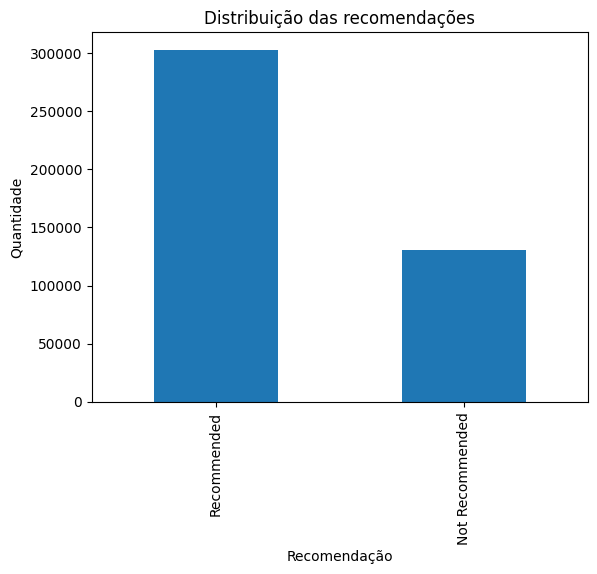

In [43]:
# Contagem de cada classe
print(df['recommendation'].value_counts())

# Gráfico de barras simples
df['recommendation'].value_counts().plot(kind='bar')
plt.title('Distribuição das recomendações')
plt.xlabel('Recomendação')
plt.ylabel('Quantidade')
plt.show()


In [44]:
# Criar coluna com o tamanho de cada review
df['review_length'] = df['tokens'].apply(len)

# Estatísticas descritivas
df['review_length'].describe()


count    433375.000000
mean         21.536791
std          46.841477
min           0.000000
25%           3.000000
50%           8.000000
75%          21.000000
max        7984.000000
Name: review_length, dtype: float64

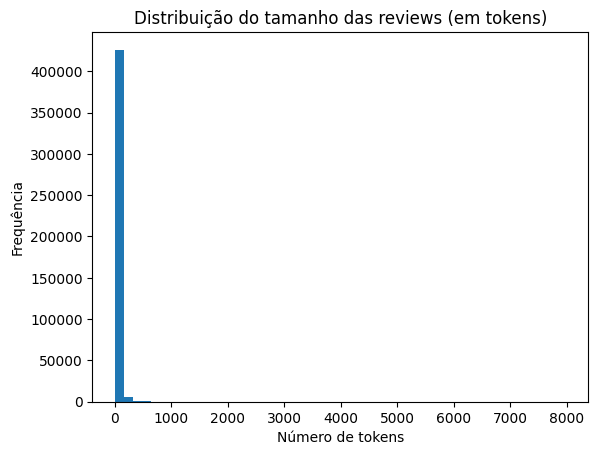

In [45]:
plt.hist(df['review_length'], bins=50)
plt.title('Distribuição do tamanho das reviews (em tokens)')
plt.xlabel('Número de tokens')
plt.ylabel('Frequência')
plt.show()


In [46]:
# Lista com todas as palavras do dataset
all_words = [word for tokens in df['tokens'] for word in tokens]

word_freq = Counter(all_words)

# Top 20 palavras mais frequentes
word_freq.most_common(20)


[('game', 494655),
 ('fun', 90681),
 ('play', 90314),
 ('get', 82915),
 ('good', 82491),
 ('like', 75905),
 ('dont', 55987),
 ('great', 53677),
 ('time', 51219),
 ('one', 48910),
 ('really', 46578),
 ('even', 46015),
 ('people', 44479),
 ('games', 43701),
 ('still', 43104),
 ('would', 41943),
 ('friends', 40250),
 ('buy', 37688),
 ('playing', 37481),
 ('best', 37220)]

In [47]:
top_words = word_freq.most_common(20)
top_words_df = pd.DataFrame(top_words, columns=['word', 'count'])
top_words_df


,word,count
0,game,494655
1,fun,90681
2,play,90314
3,get,82915
4,good,82491
5,like,75905
6,dont,55987
7,great,53677
8,time,51219
9,one,48910


In [48]:
def tokenize_for_wc(text):
    # quebra por espaço e limpa cada palavra
    words = text.split()
    cleaned = []
    for w in words:
        w = w.lower()
        w = re.sub(r'[^a-z]', '', w)  # mantém só letras
        w = w.strip()
        if w != '':
            cleaned.append(w)
    return cleaned


In [49]:
df['label'] = df['recommendation'].apply(
    lambda x: 1 if x == 'Recommended' else 0
)

df[['recommendation', 'label']].head()


,recommendation,label
0,Recommended,1
1,Recommended,1
2,Recommended,1
3,Recommended,1
4,Recommended,1


In [ ]:
# Filtrar apenas as reviews positivas
df_pos = df[df['label'] == 1]

# Juntar tudo em um texto único
text_pos = " ".join(df_pos['clean_review'].astype(str).tolist())

# Gerar lista de palavras limpas
words_pos = tokenize_for_wc(text_pos)

# transformar em string de novo
text_pos_clean = " ".join(words_pos)

# Stopwords
custom_stopwords = set(STOPWORDS)

custom_stopwords.update({'game', 'games'})  

wc_pos = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=custom_stopwords
).generate(text_pos_clean)

plt.figure(figsize=(14,7))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Reviews POSITIVAS (Recommended)')
plt.show()


In [ ]:
# Filtrar apenas as reviews negativas
df_neg = df[df['label'] == 0]

text_neg = " ".join(df_neg['clean_review'].astype(str).tolist())
words_neg = tokenize_for_wc(text_neg)
text_neg_clean = " ".join(words_neg)

wc_neg = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=custom_stopwords 
).generate(text_neg_clean)

plt.figure(figsize=(14,7))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Reviews NEGATIVAS (Not Recommended)')
plt.show()


In [ ]:
df['label'].value_counts()


Preparação dos dados para Deep Learning

1º Treinamento com a base inteira


In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer(
#      max_features=5000,       # usa as 5000 palavras mais relevantes
#      ngram_range=(1,1),       # unigrams
#      stop_words='english'     # reforça remoção de stopwords 
#  )

# X = vectorizer.fit_transform(df['clean_review']).toarray()
# y = df['label'].values

# X.shape, len(y)



 
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#      X, y,
#      test_size=0.2,
#      random_state=42,
#      stratify=y
#  )

# X_train.shape, X_test.shape


# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

# model = Sequential([
#     Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
#     Dense(1, activation='sigmoid')
# ])

# model.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

# model.summary()


# from sklearn.utils import class_weight
# import numpy as np

# weights = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )

# class_weights = {0: weights[0], 1: weights[1]}
# class_weights


# history = model.fit(
#     X_train, y_train,
#     validation_split=0.2,
#     epochs=6,
#     batch_size=512,
#     class_weight=class_weights,
#     verbose=1
# )




Testes com a base inteira explodiram a memória. Vamos realizar o procedimento com 50k linhas


Modelo 1 – Rede Neural 

In [ ]:
# Amostra para Deep Learning (50 mil linhas)
df_dl = df[['clean_review', 'label']].sample(50000, random_state=42)

len(df_dl), df_dl['label'].value_counts()


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=3000,       # reduzimos de 5000 para 3000
    ngram_range=(1,1),
    stop_words='english'
)

X = vectorizer.fit_transform(df_dl['clean_review']).toarray()
y = df_dl['label'].values

X.shape, len(y)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


In [ ]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


In [ ]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}
class_weights


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=6,
    batch_size=256,      # pode usar 256 pra aliviar um pouco
    class_weight=class_weights,
    verbose=1
)


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Acurácia no teste: {accuracy:.4f}")


Input (3000 features TF-IDF)
↓
Dense(32, relu)
↓
Dense(1, sigmoid)

Resultado:
Acurácia no teste ≈ 0.8253



Modelo 2 – Rede Neural Aprimorada

In [ ]:
model2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.summary()


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,            # espera 2 épocas sem melhorar
    restore_best_weights=True
)


In [ ]:
history2 = model2.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,             # pode pedir até 10, o EarlyStopping corta antes
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


In [ ]:
loss2, acc2 = model2.evaluate(X_test, y_test)
print(f"Acurácia no teste (Modelo 2): {acc2:.4f}")


In [ ]:
print("Modelo 1 (baseline): ~0.8253")
print(f"Modelo 2 (aprimorado): {acc2:.4f}")


In [ ]:
#import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history2.history['accuracy'], label='Treino')
plt.plot(history2.history['val_accuracy'], label='Validação')
plt.title('Acurácia - Modelo Aprimorado')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history2.history['loss'], label='Treino')
plt.plot(history2.history['val_loss'], label='Validação')
plt.title('Loss - Modelo Aprimorado')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()


Conclusões

Comparação entre os modelos

O primeiro modelo (baseline) consistiu em uma arquitetura simples, composta por uma única camada densa de 32 neurônios com ativação ReLU. Esse modelo obteve uma acurácia de 82,53% no conjunto de teste, demonstrando que a combinação de TF-IDF com redes neurais é eficaz para a tarefa de classificação de recomendações em reviews de jogos.

Para atender ao requisito de aprofundamento em Deep Learning, a arquitetura foi expandida com duas camadas densas (64 e 32 neurônios), além da inclusão de Dropout (0,3) e EarlyStopping. Essas técnicas auxiliaram na redução de overfitting e melhoraram a capacidade de generalização do modelo.

O modelo aprimorado atingiu uma acurácia de 83,66%, representando um aumento de aproximadamente 1,1 ponto percentual em relação ao modelo simples. Embora a diferença não seja extrema, ela é significativa considerando o tamanho limitado da rede e a utilização de uma amostra de 50.000 reviews, demonstrando que camadas adicionais e regularização podem trazer ganhos reais de desempenho.